In [1]:
import pandas as pd

intakes_path = "../data/raw/Austin_Animal_Center_Intakes_(10_01_2013_to_05_05_2025)_20260930.csv"

intakes = pd.read_csv(intakes_path)

intakes.head()

,Animal ID,Name,DateTime,MonthYear,Found Location,Intake Type,Intake Condition,Animal Type,Sex upon Intake,Age upon Intake,Breed,Color
0,A521520,Nina,10/01/2013 07:51:00 AM,October 2013,Norht Ec in Austin (TX),Stray,Normal,Dog,Spayed Female,7 years,Border Terrier/Border Collie,White/Tan
1,A664235,NaN,10/01/2013 08:33:00 AM,October 2013,Abia in Austin (TX),Stray,Normal,Cat,Unknown,1 week,Domestic Shorthair Mix,Orange/White
2,A664236,NaN,10/01/2013 08:33:00 AM,October 2013,Abia in Austin (TX),Stray,Normal,Cat,Unknown,1 week,Domestic Shorthair Mix,Orange/White
3,A664237,NaN,10/01/2013 08:33:00 AM,October 2013,Abia in Austin (TX),Stray,Normal,Cat,Unknown,1 week,Domestic Shorthair Mix,Orange/White
4,A664233,Stevie,10/01/2013 08:53:00 AM,October 2013,7405 Springtime in Austin (TX),Stray,Injured,Dog,Intact Female,3 years,Pit Bull Mix,Blue/White


In [2]:
intakes.shape

(173812, 12)

In [3]:
intakes["Animal ID"].nunique()

156287

In [4]:
intakes["Animal ID"].value_counts().head(10)

Animal ID
A721033    33
A718223    14
A705625    12
A718877    12
A706536    11
A761266    10
A616444     9
A700407     9
A716018     9
A717053     9
Name: count, dtype: int64

In [5]:
intakes[
    intakes["Animal ID"] == "A721033"
][["Animal ID", "Name", "DateTime", "Intake Type", "Intake Condition"]]


,Animal ID,Name,DateTime,Intake Type,Intake Condition
43498,A721033,Lil Bit,02/20/2016 10:44:00 AM,Stray,Normal
51001,A721033,Lil Bit,07/10/2016 11:53:00 AM,Stray,Normal
53835,A721033,Lil Bit,09/03/2016 02:30:00 PM,Public Assist,Normal
56121,A721033,Lil Bit,10/20/2016 10:47:00 PM,Public Assist,Normal
58575,A721033,Lil Bit,12/15/2016 10:07:00 AM,Public Assist,Normal
59568,A721033,Lil Bit,01/09/2017 02:26:00 PM,Stray,Injured
60211,A721033,Lil Bit,01/26/2017 06:55:00 AM,Public Assist,Normal
60407,A721033,Lil Bit,01/30/2017 11:05:00 PM,Public Assist,Normal
60647,A721033,Lil Bit,02/06/2017 10:13:00 AM,Public Assist,Normal
62261,A721033,Lil Bit,03/15/2017 09:24:00 AM,Public Assist,Normal


In [6]:
outcomes_path = "../data/raw/Austin_Animal_Center_Outcomes_(10_01_2013_to_05_05_2025)_20260930.csv"

outcomes = pd.read_csv(outcomes_path)

outcomes.head()

,Animal ID,Date of Birth,Name,DateTime,MonthYear,Outcome Type,Outcome Subtype,Animal Type,Sex upon Outcome,Age upon Outcome,Breed,Color
0,A668305,2012-12-01,NaN,2013-12-02T00:00:00-05:00,12-2013,Transfer,Partner,Other,Unknown,1 year,Turtle Mix,Brown/Yellow
1,A673335,2012-02-22,NaN,2014-02-22T00:00:00-05:00,02-2014,Euthanasia,Suffering,Other,Unknown,2 years,Raccoon,Black/Gray
2,A675999,2013-04-03,NaN,2014-04-07T00:00:00-05:00,04-2014,Transfer,Partner,Other,Unknown,1 year,Turtle Mix,Green
3,A679066,2014-04-16,NaN,2014-05-16T00:00:00-05:00,05-2014,NaN,NaN,Other,Unknown,4 weeks,Rabbit Sh,Brown
4,A680855,2014-05-25,NaN,2014-06-10T00:00:00-05:00,06-2014,Transfer,Partner,Bird,Unknown,2 weeks,Duck,Yellow/Black


In [7]:
outcomes["Outcome Type"].value_counts(dropna=False)

Outcome Type
Adoption           84598
Transfer           48689
Return to Owner    25691
Euthanasia         10833
Died                1672
Rto-Adopt           1241
Disposal             877
Missing               92
NaN                   46
Relocate              29
Stolen                 5
Lost                   2
Name: count, dtype: int64

In [8]:
intakes.dtypes

Animal ID           str
Name                str
DateTime            str
MonthYear           str
Found Location      str
Intake Type         str
Intake Condition    str
Animal Type         str
Sex upon Intake     str
Age upon Intake     str
Breed               str
Color               str
dtype: object

In [9]:
outcomes.dtypes

Animal ID           str
Date of Birth       str
Name                str
DateTime            str
MonthYear           str
Outcome Type        str
Outcome Subtype     str
Animal Type         str
Sex upon Outcome    str
Age upon Outcome    str
Breed               str
Color               str
dtype: object

In [10]:
intakes["DateTime"] = pd.to_datetime(intakes["DateTime"])

intakes["DateTime"].dtype

dtype('<M8[us]')

In [11]:
outcomes["DateTime"] = pd.to_datetime(outcomes["DateTime"])

outcomes["DateTime"].dtype

ValueError: time data "2013-10-01T09:31:00" doesn't match format "%Y-%m-%dT%H:%M:%S%z". You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.

In [12]:
outcomes["DateTime"] = pd.to_datetime(
    outcomes["DateTime"],
    format="mixed"
)

ValueError: Mixed timezones detected. Pass utc=True in to_datetime or tz='UTC' in DatetimeIndex to convert to a common timezone.

In [13]:
outcomes["DateTime"] = pd.to_datetime(
    outcomes["DateTime"],
    format="mixed",
    utc=True
)

outcomes["DateTime"].dtype

datetime64[us, UTC]

In [14]:
outcomes["DateTime"] = outcomes["DateTime"].dt.tz_localize(None)

In [15]:
print(intakes["DateTime"].dtype)
print(outcomes["DateTime"].dtype)

datetime64[us]
datetime64[us]


In [16]:
adoptions = outcomes[
    outcomes["Outcome Type"] == "Adoption"
].copy()

adoptions.shape

(84598, 12)

In [17]:
adoptions["Animal ID"].value_counts().head(10)

Animal ID
A754989    8
A770009    7
A683030    6
A732618    6
A740335    6
A746563    6
A753485    6
A737854    6
A775940    6
A798240    6
Name: count, dtype: int64

In [18]:
adoptions[
    adoptions["Animal ID"] == "A754989"
][["Animal ID", "Name", "DateTime", "Outcome Type"]]

,Animal ID,Name,DateTime,Outcome Type
70309,A754989,Molly,2017-07-29 18:39:00,Adoption
93259,A754989,Molly,2018-12-17 18:15:00,Adoption
94634,A754989,Molly,2019-01-18 19:17:00,Adoption
94655,A754989,Molly,2019-01-19 13:40:00,Adoption
95936,A754989,Molly,2019-02-19 19:04:00,Adoption
108469,A754989,Molly,2019-09-08 14:43:00,Adoption
109185,A754989,Molly,2019-09-19 17:46:00,Adoption
111244,A754989,Molly,2019-10-26 16:06:00,Adoption


In [19]:
intakes[
    intakes["Animal ID"] == "A754989"
][["Animal ID", "Name", "DateTime", "Intake Type"]]

,Animal ID,Name,DateTime,Intake Type
69658,A754989,Molly,2017-07-27 14:54:00,Owner Surrender
92893,A754989,Molly,2018-12-06 15:46:00,Owner Surrender
93993,A754989,Molly,2019-01-06 15:52:00,Owner Surrender
94534,A754989,Molly,2019-01-19 11:20:00,Owner Surrender
95688,A754989,Molly,2019-02-18 11:00:00,Owner Surrender
107510,A754989,Molly,2019-09-04 13:50:00,Owner Surrender
108170,A754989,Molly,2019-09-14 18:19:00,Owner Surrender
109095,A754989,Molly,2019-09-29 16:15:00,Owner Surrender


In [20]:
adoptions = adoptions.rename(
    columns={"DateTime": "Adoption DateTime"}
)

intakes = intakes.rename(
    columns={"DateTime": "Intake DateTime"}
)

In [21]:
print(adoptions["Adoption DateTime"].dtype)
print(intakes["Intake DateTime"].dtype)

datetime64[us]
datetime64[us]


In [22]:
adoptions_sorted = adoptions.sort_values("Adoption DateTime")

intakes_sorted = intakes.sort_values("Intake DateTime")

In [25]:
adoption_returns = pd.merge_asof(
    adoptions_sorted,
    intakes_sorted,
    left_on="Adoption DateTime",
    right_on="Intake DateTime",
    by="Animal ID",
    direction="forward"
)

In [26]:
adoption_returns.shape

(84598, 23)

In [27]:
adoption_returns["Days to Next Intake"] = (
    adoption_returns["Intake DateTime"]
    - adoption_returns["Adoption DateTime"]
).dt.total_seconds() / 86400

In [28]:
adoption_returns["Days to Next Intake"].describe()

count    10579.000000
mean       214.496174
std        437.682428
min          0.000000
25%          5.004514
50%         27.892361
75%        197.868750
max       3765.959028
Name: Days to Next Intake, dtype: float64

In [29]:
for days in [30, 90, 365]:
    count = (adoption_returns["Days to Next Intake"] <= days).sum()
    rate = count / len(adoption_returns) * 100

    print(f"{days} days: {count:,} returns ({rate:.2f}%)")

30 days: 5,408 returns (6.39%)
90 days: 6,760 returns (7.99%)
365 days: 8,821 returns (10.43%)


In [30]:
returns_30 = adoption_returns[
    adoption_returns["Days to Next Intake"] <= 30
]

returns_30["Intake Type"].value_counts()

Intake Type
Owner Surrender    5055
Stray               262
Public Assist        80
Abandoned            11
Name: count, dtype: int64

In [31]:
returns_30["Days to Next Intake"].describe()

count    5408.000000
mean        8.265419
std         7.966834
min         0.000000
25%         1.884375
50%         5.150000
75%        12.871354
max        29.995833
Name: Days to Next Intake, dtype: float64

In [32]:
%pip install matplotlib

  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached kiwisolver-1.5.1-cp314-cp314-win_amd64.whl.metadata (5.2 kB)
  Using cached pillow-12.3.0-cp314-cp314-win_amd64.whl.metadata (9.3 kB)
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---- ----------------------------------- 1.0/9.5 MB 5.7 MB/s eta 0:00:02
   ------------ --------------------------- 2.9/9.5 MB 7.3 MB/s eta 0:00:01
   ---------------------- ----------------- 5.2/9.5 MB 9.0 MB/s eta 0:00:01
   ------------------------------------- -- 8.9/9.5 MB 11.4 MB/s eta 0:00:01
   ---------------------------------------- 9.5/9.5 MB 11.3 MB/s  0:00:00
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ---------------------------------------- 0.0/2.5 MB ? eta -:--:--
   ---------------------------------------- 2.5/2.5 MB 20.6 MB/s  0:00:00
Using cached kiwisolver-1.5.1-cp314-cp314-win_amd64.whl (72 kB)
Using cached pillow-12.3.0-cp314-cp314-win_amd64.whl (7.2 MB)

   -------------


[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


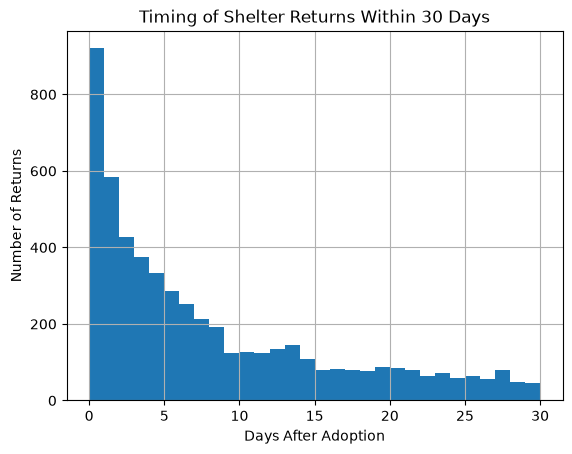

In [33]:
import matplotlib.pyplot as plt

returns_30["Days to Next Intake"].hist(
    bins=30
)

plt.xlabel("Days After Adoption")
plt.ylabel("Number of Returns")
plt.title("Timing of Shelter Returns Within 30 Days")
plt.show()

In [34]:
for days in [1, 3, 7, 14, 30]:
    count = (returns_30["Days to Next Intake"] <= days).sum()
    pct = count / len(returns_30) * 100

    print(f"Within {days:2} days: {count:,} ({pct:.1f}%)")

Within  1 days: 922 (17.0%)
Within  3 days: 1,931 (35.7%)
Within  7 days: 3,181 (58.8%)
Within 14 days: 4,236 (78.3%)
Within 30 days: 5,408 (100.0%)


In [35]:
adoption_returns["Returned Within 30 Days"] = (
    adoption_returns["Days to Next Intake"] <= 30
)

In [36]:
return_by_type = adoption_returns.groupby(
    "Animal Type_x"
)["Returned Within 30 Days"].agg(["count", "sum", "mean"])

return_by_type

,count,sum,mean
Animal Type_x,,,
Bird,323,1,0.003096
Cat,35781,1108,0.030966
Dog,47475,4285,0.090258
Livestock,17,0,0.000000
Other,1002,14,0.013972


In [37]:
dogs = adoption_returns[
    adoption_returns["Animal Type_x"] == "Dog"
]

dogs.groupby(
    "Sex upon Outcome"
)["Returned Within 30 Days"].agg(["count", "sum", "mean"])

,count,sum,mean
Sex upon Outcome,,,
Intact Female,704,62,0.088068
Intact Male,655,70,0.106870
Neutered Male,23750,2283,0.096126
Spayed Female,22342,1870,0.083699
Unknown,24,0,0.000000


In [38]:
adoption_returns["Age upon Outcome"].value_counts().head(20)

Age upon Outcome
2 months     19663
1 year       13068
2 years      11461
3 months      7175
4 months      4228
3 years       4016
1 month       3175
5 months      2851
6 months      2365
4 years       2324
5 years       2019
8 months      1643
10 months     1480
7 months      1407
6 years       1264
8 years       1140
7 years       1114
9 months       970
10 years       727
11 months      687
Name: count, dtype: int64

In [39]:
def age_to_years(age):
    if pd.isna(age):
        return None

    number, unit = age.split()

    number = int(number)

    if "year" in unit:
        return number
    elif "month" in unit:
        return number / 12
    elif "week" in unit:
        return number / 52
    elif "day" in unit:
        return number / 365

In [40]:
adoption_returns["Age Years"] = (
    adoption_returns["Age upon Outcome"].apply(age_to_years)
)

In [41]:
adoption_returns[
    ["Age upon Outcome", "Age Years"]
].head(10)

,Age upon Outcome,Age Years
0,2 months,0.166667
1,3 years,3.000000
2,6 months,0.500000
3,5 months,0.416667
4,3 years,3.000000
5,2 months,0.166667
6,2 months,0.166667
7,8 months,0.666667
8,2 months,0.166667
9,2 months,0.166667


In [42]:
adoption_returns["Age Group"] = pd.cut(
    adoption_returns["Age Years"],
    bins=[0, 1, 3, 7, 10, float("inf")],
    labels=["Under 1", "1–2", "3–6", "7–9", "10+"],
    right=False
)

In [43]:
adoption_returns.groupby(
    "Age Group",
    observed=True
)["Returned Within 30 Days"].agg(["count", "sum", "mean"])

,count,sum,mean
Age Group,,,
Under 1,45714,1787,0.039091
1–2,24529,2318,0.094500
3–6,9623,941,0.097787
7–9,2914,254,0.087165
10+,1815,108,0.059504


In [44]:
age_by_type = adoption_returns.groupby(
    ["Animal Type_x", "Age Group"],
    observed=True
)["Returned Within 30 Days"].agg(["count", "sum", "mean"])

age_by_type.loc[["Dog", "Cat"]]

count   sum      mean
Animal Type_x Age Group                       
Dog           Under 1    19108  1173  0.061388
              1–2        18129  2045  0.112803
              3–6         7169   801  0.111731
              7–9         2010   203  0.100995
              10+         1057    63  0.059603
Cat           Under 1    26204   610  0.023279
              1–2         5567   264  0.047422
              3–6         2361   139  0.058873
              7–9          893    50  0.055991
              10+          755    45  0.059603

In [45]:
data_end = intakes["Intake DateTime"].max()

data_end

Timestamp('2025-05-04 23:44:00')

In [46]:
followup_cutoff = data_end - pd.Timedelta(days=30)

followup_cutoff

Timestamp('2025-04-04 23:44:00')

In [47]:
adoption_returns_30 = adoption_returns[
    adoption_returns["Adoption DateTime"] <= followup_cutoff
].copy()

adoption_returns_30.shape

(84154, 27)

In [48]:
adoption_returns_30["Returned Within 30 Days"] = (
    adoption_returns_30["Days to Next Intake"] <= 30
)

In [49]:
adoption_returns_30["Returned Within 30 Days"].agg(
    ["count", "sum", "mean"]
)

count    84154.000000
sum       5390.000000
mean         0.064049
Name: Returned Within 30 Days, dtype: float64

In [50]:
adoption_returns_30.groupby(
    "Animal Type_x"
)["Returned Within 30 Days"].agg(["count", "sum", "mean"])

,count,sum,mean
Animal Type_x,,,
Bird,322,1,0.003106
Cat,35565,1103,0.031014
Dog,47256,4272,0.090401
Livestock,17,0,0.000000
Other,994,14,0.014085


In [51]:
intake_history = intakes[
    ["Animal ID", "Intake DateTime"]
].copy()

intake_history.head()

,Animal ID,Intake DateTime
0,A521520,2013-10-01 07:51:00
1,A664235,2013-10-01 08:33:00
2,A664236,2013-10-01 08:33:00
3,A664237,2013-10-01 08:33:00
4,A664233,2013-10-01 08:53:00


In [53]:
intake_history = intake_history.sort_values(
    ["Animal ID", "Intake DateTime"]
)

intake_history.head(10)

,Animal ID,Intake DateTime
6926,A006100,2014-03-07 14:26:00
22374,A006100,2014-12-19 10:21:00
75925,A006100,2017-12-07 14:07:00
8236,A047759,2014-04-02 15:55:00
2309,A134067,2013-11-16 09:02:00
2347,A141142,2013-11-16 14:46:00
20836,A163459,2014-11-14 15:11:00
17759,A165752,2014-09-15 11:28:00
80483,A169438,2018-04-04 20:37:00
7385,A178569,2014-03-17 09:45:00


In [54]:
intake_history["Intake Number"] = (
    intake_history.groupby("Animal ID").cumcount() + 1
)

intake_history.head(10)

,Animal ID,Intake DateTime,Intake Number
6926,A006100,2014-03-07 14:26:00,1
22374,A006100,2014-12-19 10:21:00,2
75925,A006100,2017-12-07 14:07:00,3
8236,A047759,2014-04-02 15:55:00,1
2309,A134067,2013-11-16 09:02:00,1
2347,A141142,2013-11-16 14:46:00,1
20836,A163459,2014-11-14 15:11:00,1
17759,A165752,2014-09-15 11:28:00,1
80483,A169438,2018-04-04 20:37:00,1
7385,A178569,2014-03-17 09:45:00,1


In [55]:
adoptions_30_sorted = adoption_returns_30.sort_values(
    "Adoption DateTime"
)

In [56]:
intake_history_time = intake_history.sort_values(
    "Intake DateTime"
)

In [57]:
adoptions_with_history = pd.merge_asof(
    adoptions_30_sorted,
    intake_history_time,
    left_on="Adoption DateTime",
    right_on="Intake DateTime",
    by="Animal ID",
    direction="backward"
)

In [58]:
adoptions_with_history[
    [
        "Animal ID",
        "Adoption DateTime",
        "Intake DateTime_y",
        "Intake Number",
        "Returned Within 30 Days"
    ]
].head(10)

,Animal ID,Adoption DateTime,Intake DateTime_y,Intake Number,Returned Within 30 Days
0,A659834,2013-10-01 09:31:00,NaT,NaN,False
1,A663572,2013-10-01 11:42:00,NaT,NaN,True
2,A661795,2013-10-01 11:53:00,NaT,NaN,False
3,A656894,2013-10-01 11:53:00,NaT,NaN,False
4,A662104,2013-10-01 15:47:00,NaT,NaN,False
5,A660634,2013-10-01 16:17:00,NaT,NaN,False
6,A663920,2013-10-01 16:53:00,NaT,NaN,False
7,A663827,2013-10-01 17:02:00,NaT,NaN,False
8,A664032,2013-10-01 17:18:00,NaT,NaN,False
9,A664031,2013-10-01 18:24:00,NaT,NaN,False


In [59]:
adoptions_with_history["Intake Number"].isna().agg(["sum", "mean"])

sum     630.000000
mean      0.007486
Name: Intake Number, dtype: float64

In [60]:
adoptions_with_history.groupby(
    "Intake Number"
)["Returned Within 30 Days"].agg(["count", "sum", "mean"]).head(10)

,count,sum,mean
Intake Number,,,
1.0,74358,4259,0.057277
2.0,7332,813,0.110884
3.0,1339,194,0.144884
4.0,339,58,0.171091
5.0,102,11,0.107843
6.0,33,5,0.151515
7.0,15,2,0.133333
8.0,4,0,0.000000
9.0,2,0,0.000000


In [61]:
adoptions_with_history["Has Prior Shelter History"] = (
    adoptions_with_history["Intake Number"] > 1
)

In [62]:
adoptions_with_history.groupby(
    "Has Prior Shelter History"
)["Returned Within 30 Days"].agg(["count", "sum", "mean"])

,count,sum,mean
Has Prior Shelter History,,,
False,74988,4307,0.057436
True,9166,1083,0.118154


In [63]:
history_analysis = adoptions_with_history.dropna(
    subset=["Intake Number"]
).copy()

In [64]:
history_analysis["Has Prior Shelter History"] = (
    history_analysis["Intake Number"] > 1
)

In [65]:
history_analysis.groupby(
    "Has Prior Shelter History"
)["Returned Within 30 Days"].agg(["count", "sum", "mean"])

,count,sum,mean
Has Prior Shelter History,,,
False,74358,4259,0.057277
True,9166,1083,0.118154


In [66]:
history_analysis = history_analysis.rename(
    columns={"Intake DateTime_y": "Pre-Adoption Intake DateTime"}
)

In [67]:
history_analysis["Length of Stay Days"] = (
    history_analysis["Adoption DateTime"]
    - history_analysis["Pre-Adoption Intake DateTime"]
).dt.total_seconds() / 86400

In [68]:
history_analysis["Length of Stay Days"].describe()

count    83524.000000
mean        34.916097
std         61.672110
min          0.000000
25%          5.298611
50%         14.058333
75%         43.019444
max       1912.938194
Name: Length of Stay Days, dtype: float64

In [69]:
history_analysis.nlargest(
    10,
    "Length of Stay Days"
)[
    [
        "Animal ID",
        "Pre-Adoption Intake DateTime",
        "Adoption DateTime",
        "Length of Stay Days"
    ]
]

,Animal ID,Pre-Adoption Intake DateTime,Adoption DateTime,Length of Stay Days
55623,A642712,2016-01-05 11:37:00,2021-04-01 10:08:00,1912.938194
66935,A764237,2017-12-26 12:08:00,2022-10-06 10:41:00,1744.939583
51871,A722987,2016-03-24 16:59:00,2020-05-24 16:30:00,1521.979861
43392,A702369,2015-05-12 16:45:00,2019-05-21 09:54:00,1469.714583
43567,A707965,2015-07-20 17:12:00,2019-05-28 09:45:00,1407.689583
73478,A810081,2020-01-21 12:36:00,2023-10-10 08:26:00,1357.826389
55658,A762152,2017-11-15 13:09:00,2021-04-03 14:01:00,1235.036111
60851,A778611,2018-08-17 14:37:00,2021-11-24 14:43:00,1195.004167
82319,A843014,2021-09-25 08:19:00,2024-12-27 09:20:00,1189.042361
78395,A745344,2021-04-14 15:10:00,2024-06-27 15:39:00,1170.020139


In [70]:
intakes[
    intakes["Animal ID"] == "A642712"
][
    ["Animal ID", "Intake DateTime", "Intake Type"]
]

,Animal ID,Intake DateTime,Intake Type
41720,A642712,2016-01-05 11:37:00,Stray


In [71]:
outcomes[
    outcomes["Animal ID"] == "A642712"
][
    ["Animal ID", "DateTime", "Outcome Type", "Outcome Subtype"]
].sort_values("DateTime")

,Animal ID,DateTime,Outcome Type,Outcome Subtype
125972,A642712,2021-04-01 10:08:00,Adoption,Foster


In [72]:
history_analysis = history_analysis.rename(
    columns={"Length of Stay Days": "Days Intake to Adoption"}
)

In [73]:
history_analysis["Intake to Adoption Group"] = pd.cut(
    history_analysis["Days Intake to Adoption"],
    bins=[0, 7, 14, 30, 60, 90, float("inf")],
    labels=[
        "Under 7 days",
        "7–13 days",
        "14–29 days",
        "30–59 days",
        "60–89 days",
        "90+ days"
    ],
    right=False
)

In [74]:
history_analysis.groupby(
    "Intake to Adoption Group",
    observed=True
)["Returned Within 30 Days"].agg(["count", "sum", "mean"])

,count,sum,mean
Intake to Adoption Group,,,
Under 7 days,26965,1784,0.066160
7–13 days,14643,1062,0.072526
14–29 days,13191,937,0.071033
30–59 days,15180,838,0.055204
60–89 days,6741,320,0.047471
90+ days,6804,401,0.058936


In [75]:
history_analysis["Breed_x"].value_counts().head(20)

Breed_x
Domestic Shorthair Mix       15497
Domestic Shorthair           13572
Labrador Retriever Mix        4853
Pit Bull Mix                  4297
Chihuahua Shorthair Mix       3298
German Shepherd Mix           2272
Pit Bull                      1724
Domestic Medium Hair Mix      1650
Domestic Medium Hair          1300
Australian Cattle Dog Mix     1153
German Shepherd               1055
Labrador Retriever            1037
Chihuahua Shorthair            935
Domestic Longhair Mix          846
Siamese Mix                    747
Border Collie Mix              659
Dachshund Mix                  587
Boxer Mix                      571
Siberian Husky Mix             533
Catahoula Mix                  479
Name: count, dtype: int64

In [76]:
history_analysis["Is Mix"] = (
    history_analysis["Breed_x"]
    .str.contains("Mix", case=False, na=False)
)

In [77]:
history_analysis.groupby(
    "Is Mix"
)["Returned Within 30 Days"].agg(["count", "sum", "mean"])

,count,sum,mean
Is Mix,,,
False,34199,2005,0.058627
True,49325,3337,0.067653


In [78]:
history_analysis[
    history_analysis["Animal Type_x"] == "Dog"
].groupby(
    "Is Mix"
)["Returned Within 30 Days"].agg(["count", "sum", "mean"])

,count,sum,mean
Is Mix,,,
False,17374,1558,0.089674
True,29586,2689,0.090888


In [79]:
model_data = history_analysis[
    [
        "Returned Within 30 Days",
        "Animal Type_x",
        "Sex upon Outcome",
        "Age Years",
        "Has Prior Shelter History",
        "Days Intake to Adoption"
    ]
].copy()

model_data.head()

,Returned Within 30 Days,Animal Type_x,Sex upon Outcome,Age Years,Has Prior Shelter History,Days Intake to Adoption
14,False,Dog,Spayed Female,2.000000,False,0.910417
76,False,Dog,Neutered Male,0.166667,False,1.317361
77,False,Dog,Neutered Male,0.166667,False,1.318056
86,False,Dog,Spayed Female,0.166667,False,2.046528
99,False,Dog,Spayed Female,0.166667,False,5.040278


In [80]:
model_data.isna().sum()

Returned Within 30 Days      0
Animal Type_x                0
Sex upon Outcome             0
Age Years                    0
Has Prior Shelter History    0
Days Intake to Adoption      0
dtype: int64

In [81]:
model_data["Returned Within 30 Days"].value_counts()

Returned Within 30 Days
False    78182
True      5342
Name: count, dtype: int64

In [82]:
model_data["Returned Within 30 Days"].value_counts(normalize=True)

Returned Within 30 Days
False    0.936042
True     0.063958
Name: proportion, dtype: float64

In [83]:
%pip install scikit-learn

  Using cached cloudpickle-3.1.2-py3-none-any.whl.metadata (7.1 kB)
   ---------------------------------------- 0.0/8.4 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.4 MB 3.2 MB/s eta 0:00:03
   ------- -------------------------------- 1.6/8.4 MB 4.0 MB/s eta 0:00:02
   ------------- -------------------------- 2.9/8.4 MB 5.0 MB/s eta 0:00:02
   --------------------- ------------------ 4.5/8.4 MB 5.7 MB/s eta 0:00:01
   -------------------------------- ------- 6.8/8.4 MB 7.0 MB/s eta 0:00:01
   ---------------------------------------- 8.4/8.4 MB 7.6 MB/s  0:00:01
Using cached cloudpickle-3.1.2-py3-none-any.whl (22 kB)
   ---------------------------------------- 0.0/37.4 MB ? eta -:--:--
   ---- ----------------------------------- 3.9/37.4 MB 19.7 MB/s eta 0:00:02
   ---------- ----------------------------- 9.4/37.4 MB 23.3 MB/s eta 0:00:02
   ------------------ --------------------- 17.3/37.4 MB 28.3 MB/s eta 0:00:01
   ------------------------------ --------- 28.8/


[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [84]:
X = model_data.drop(columns=["Returned Within 30 Days"])
y = model_data["Returned Within 30 Days"]

In [85]:
X.head()

,Animal Type_x,Sex upon Outcome,Age Years,Has Prior Shelter History,Days Intake to Adoption
14,Dog,Spayed Female,2.000000,False,0.910417
76,Dog,Neutered Male,0.166667,False,1.317361
77,Dog,Neutered Male,0.166667,False,1.318056
86,Dog,Spayed Female,0.166667,False,2.046528
99,Dog,Spayed Female,0.166667,False,5.040278


In [86]:
y.head()

14    False
76    False
77    False
86    False
99    False
Name: Returned Within 30 Days, dtype: bool

In [87]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

Training rows: 66819
Testing rows: 16705


In [88]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

categorical_features = [
    "Animal Type_x",
    "Sex upon Outcome"
]

numeric_features = [
    "Age Years",
    "Has Prior Shelter History",
    "Days Intake to Adoption"
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(drop="first", handle_unknown="ignore"),
            categorical_features
        )
    ],
    remainder="passthrough"
)

In [89]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

categorical_features = [
    "Animal Type_x",
    "Sex upon Outcome"
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(drop="first", handle_unknown="ignore"),
            categorical_features
        )
    ],
    remainder="passthrough"
)

In [90]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

In [91]:
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[bool](2,)","[False, True]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](5,)","['Animal Type_x','Sex upon Outcome','Age Years', 'Has Prior Shelter History','Days Intake to Adoption']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,5
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``rem

In [92]:
y_prob = model.predict_proba(X_test)[:, 1]

y_prob[:10]

array([0.06649452, 0.03424461, 0.02692226, 0.02471922, 0.02674191,
       0.02485259, 0.04537303, 0.09041328, 0.09064719, 0.07208725])

In [93]:
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC:", roc_auc)

ROC-AUC: 0.6598281433716584


In [94]:
from sklearn.metrics import average_precision_score

pr_auc = average_precision_score(y_test, y_prob)

print("PR-AUC:", pr_auc)

PR-AUC: 0.10347107502827585


In [95]:
import numpy as np

feature_names = model.named_steps[
    "preprocessor"
].get_feature_names_out()

coefficients = model.named_steps[
    "classifier"
].coef_[0]

odds_ratios = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients,
    "Odds Ratio": np.exp(coefficients)
})

odds_ratios

,Feature,Coefficient,Odds Ratio
0,cat__Animal Type_x_Cat,-0.418465,0.658056
1,cat__Animal Type_x_Dog,0.607454,1.835752
2,cat__Animal Type_x_Livestock,-0.060931,0.940888
3,cat__Animal Type_x_Other,-1.748609,0.174016
4,cat__Sex upon Outcome_Intact Male,0.060750,1.062634
5,cat__Sex upon Outcome_Neutered Male,0.020966,1.021187
6,cat__Sex upon Outcome_Spayed Female,-0.150920,0.859916
7,cat__Sex upon Outcome_Unknown,-0.965024,0.380974
8,remainder__Age Years,0.050633,1.051937
9,remainder__Has Prior Shelter History,0.570363,1.768910


In [96]:
model_data["Age Group"] = history_analysis["Age Group"]

model_data["Age Group"].value_counts()

Age Group
Under 1    45178
1–2        24211
3–6         9473
7–9         2869
10+         1790
Name: count, dtype: int64

In [97]:
model_data[
    model_data["Age Group"].isna()
]

,Returned Within 30 Days,Animal Type_x,Sex upon Outcome,Age Years,Has Prior Shelter History,Days Intake to Adoption,Age Group
20706,False,Dog,Neutered Male,-3.0,False,42.068056,NaN
39316,False,Cat,Intact Female,-4.0,False,7.036806,NaN
41713,False,Dog,Neutered Male,-1.0,True,0.131250,NaN


In [98]:
model_data.loc[
    model_data["Age Years"] < 0,
    ["Age Years", "Age Group"]
] = [np.nan, np.nan]

In [99]:
model_data["Age Years"].isna().sum()

np.int64(3)

In [100]:
model_data_v2 = model_data.dropna(
    subset=["Age Group"]
).copy()

In [101]:
model_data_v2.shape

(83521, 7)

In [102]:
X = model_data_v2.drop(
    columns=["Returned Within 30 Days", "Age Years"]
)

y = model_data_v2["Returned Within 30 Days"]

In [103]:
X.head()

,Animal Type_x,Sex upon Outcome,Has Prior Shelter History,Days Intake to Adoption,Age Group
14,Dog,Spayed Female,False,0.910417,1–2
76,Dog,Neutered Male,False,1.317361,Under 1
77,Dog,Neutered Male,False,1.318056,Under 1
86,Dog,Spayed Female,False,2.046528,Under 1
99,Dog,Spayed Female,False,5.040278,Under 1


In [104]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

categorical_features = [
    "Animal Type_x",
    "Sex upon Outcome",
    "Age Group"
]

preprocessor_v2 = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(
                drop=[
                    "Cat",
                    "Intact Female",
                    "Under 1"
                ],
                handle_unknown="ignore"
            ),
            categorical_features
        )
    ],
    remainder="passthrough"
)

In [105]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [106]:
model_v2 = Pipeline([
    ("preprocessor", preprocessor_v2),
    ("classifier", LogisticRegression(max_iter=1000))
])

model_v2.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[bool](2,)","[False, True]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](5,)","['Animal Type_x','Sex upon Outcome','Has Prior Shelter History', 'Days Intake to Adoption','Age Group']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,5
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``rem

In [107]:
y_prob_v2 = model_v2.predict_proba(X_test)[:, 1]

In [108]:
roc_auc_v2 = roc_auc_score(y_test, y_prob_v2)
pr_auc_v2 = average_precision_score(y_test, y_prob_v2)

print("ROC-AUC:", roc_auc_v2)
print("PR-AUC:", pr_auc_v2)

ROC-AUC: 0.6729776849731466
PR-AUC: 0.1104195523839943


In [109]:
feature_names_v2 = model_v2.named_steps[
    "preprocessor"
].get_feature_names_out()

coefficients_v2 = model_v2.named_steps[
    "classifier"
].coef_[0]

odds_ratios_v2 = pd.DataFrame({
    "Feature": feature_names_v2,
    "Coefficient": coefficients_v2,
    "Odds Ratio": np.exp(coefficients_v2)
})

odds_ratios_v2

,Feature,Coefficient,Odds Ratio
0,cat__Animal Type_x_Bird,-0.957250,0.383947
1,cat__Animal Type_x_Dog,0.861616,2.366984
2,cat__Animal Type_x_Livestock,-0.049130,0.952057
3,cat__Animal Type_x_Other,-1.160831,0.313226
4,cat__Sex upon Outcome_Intact Male,0.262332,1.299958
5,cat__Sex upon Outcome_Neutered Male,0.019456,1.019646
6,cat__Sex upon Outcome_Spayed Female,-0.130405,0.877739
7,cat__Sex upon Outcome_Unknown,-0.819250,0.440762
8,cat__Age Group_10+,0.309583,1.362856
9,cat__Age Group_1–2,0.673907,1.961887


In [110]:
%pip install statsmodels

   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
   --- ------------------------------------ 1.0/11.3 MB 9.6 MB/s eta 0:00:02
   ------------ --------------------------- 3.7/11.3 MB 12.0 MB/s eta 0:00:01
   -------------------------- ------------- 7.6/11.3 MB 14.9 MB/s eta 0:00:01
   ---------------------------------------- 11.3/11.3 MB 16.1 MB/s  0:00:00

   -------- ------------------------------- 1/5 [patsy]
   ---------------- ----------------------- 2/5 [interface-meta]
   ------------------------ --------------- 3/5 [formulaic]
   ------------------------ --------------- 3/5 [formulaic]
   -------------------------------- ------- 4/5 [statsmodels]
   -------------------------------- ------- 4/5 [statsmodels]
   -------------------------------- ------- 4/5 [statsmodels]
   -------------------------------- ------- 4/5 [statsmodels]
   -------------------------------- ------- 4/5 [statsmodels]
   -------------------------------- ------- 4/5 [statsmodels]
   ----


[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [111]:
import statsmodels.formula.api as smf

In [112]:
stats_model = smf.logit(
    formula="""
        Q("Returned Within 30 Days") ~
        C(Q("Animal Type_x"), Treatment(reference="Cat")) +
        C(Q("Sex upon Outcome"), Treatment(reference="Intact Female")) +
        C(Q("Age Group"), Treatment(reference="Under 1")) +
        Q("Has Prior Shelter History") +
        Q("Days Intake to Adoption")
    """,
    data=model_data_v2
).fit()

ValueError: endog has evaluated to an array with multiple columns that has shape (83521, 2). This occurs when the variable converted to endog is non-numeric (e.g., bool or str).

In [113]:
model_data_v2["Returned_30"] = (
    model_data_v2["Returned Within 30 Days"].astype(int)
)

In [114]:
stats_model = smf.logit(
    formula="""
        Returned_30 ~
        C(Q("Animal Type_x"), Treatment(reference="Cat")) +
        C(Q("Sex upon Outcome"), Treatment(reference="Intact Female")) +
        C(Q("Age Group"), Treatment(reference="Under 1")) +
        Q("Has Prior Shelter History") +
        Q("Days Intake to Adoption")
    """,
    data=model_data_v2
).fit()

         Current function value: 0.224908
         Iterations: 35


C:\Users\marky\shelter-return-analysis\.venv\Lib\site-packages\statsmodels\discrete\discrete_model.py:268: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(


In [115]:
pd.crosstab(
    model_data_v2["Animal Type_x"],
    model_data_v2["Returned_30"]
)

Returned_30,0,1
Animal Type_x,,
Bird,321,0
Cat,34151,1081
Dog,42711,4247
Livestock,17,0
Other,979,14


In [116]:
dog_cat_data = model_data_v2[
    model_data_v2["Animal Type_x"].isin(["Dog", "Cat"])
].copy()

In [117]:
dog_cat_data["Animal Type_x"].value_counts()

Animal Type_x
Dog    46958
Cat    35232
Name: count, dtype: int64

In [118]:
stats_model = smf.logit(
    formula="""
        Returned_30 ~
        C(Q("Animal Type_x"), Treatment(reference="Cat")) +
        C(Q("Sex upon Outcome"), Treatment(reference="Intact Female")) +
        C(Q("Age Group"), Treatment(reference="Under 1")) +
        Q("Has Prior Shelter History") +
        Q("Days Intake to Adoption")
    """,
    data=dog_cat_data
).fit()

         Current function value: 0.227694
         Iterations: 35


C:\Users\marky\shelter-return-analysis\.venv\Lib\site-packages\statsmodels\discrete\discrete_model.py:268: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(


In [119]:
print("SEX:")
print(pd.crosstab(
    dog_cat_data["Sex upon Outcome"],
    dog_cat_data["Returned_30"]
))

print("\nAGE:")
print(pd.crosstab(
    dog_cat_data["Age Group"],
    dog_cat_data["Returned_30"]
))

SEX:
Returned_30           0     1
Sex upon Outcome             
Intact Female      1427    87
Intact Male        1204    86
Neutered Male     37334  2815
Spayed Female     36872  2340
Unknown              25     0

AGE:
Returned_30      0     1
Age Group               
Under 1      43017  1763
1–2          21101  2284
3–6           8454   926
7–9           2608   250
10+           1682   105


In [120]:
inference_data = dog_cat_data[
    dog_cat_data["Sex upon Outcome"] != "Unknown"
].copy()

inference_data.shape

(82165, 8)

In [121]:
stats_model = smf.logit(
    formula="""
        Returned_30 ~
        C(Q("Animal Type_x"), Treatment(reference="Cat")) +
        C(Q("Sex upon Outcome"), Treatment(reference="Intact Female")) +
        C(Q("Age Group"), Treatment(reference="Under 1")) +
        Q("Has Prior Shelter History") +
        Q("Days Intake to Adoption")
    """,
    data=inference_data
).fit()

Optimization terminated successfully.
         Current function value: 0.227763
         Iterations 7


In [122]:
stats_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:            Returned_30   No. Observations:                82165
Model:                          Logit   Df Residuals:                    82154
Method:                           MLE   Df Model:                           10
Date:                Wed, 30 Sep 2026   Pseudo R-squ.:                 0.05137
Time:                        09:13:35   Log-Likelihood:                -18714.
converged:                       True   LL-Null:                       -19727.
Covariance Type:            nonrobust   LLR p-value:                     0.000
===================================================================================================================================================
                                                                                      coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------------------------------------------------
Intercept                                                                          -3.5042      0.115    -30.475      0.000      -3.730      -3.279
C(Q("Animal Type_x"), Treatment(reference="Cat"))[T.Dog]                            0.8626      0.037     23.584      0.000       0.791       0.934
C(Q("Sex upon Outcome"), Treatment(reference="Intact Female"))[T.Intact Male]       0.1087      0.159      0.683      0.494      -0.203       0.420
C(Q("Sex upon Outcome"), Treatment(reference="Intact Female"))[T.Neutered Male]    -0.0750      0.114     -0.658      0.510      -0.298       0.148
C(Q("Sex upon Outcome"), Treatment(reference="Intact Female"))[T.Spayed Female]    -0.2022      0.114     -1.772      0.076      -0.426       0.021
C(Q("Age Group"), Treatment(reference="Under 1"))[T.1–2]                            0.6744      0.035     19.515      0.000       0.607       0.742
C(Q("Age Group"), Treatment(reference="Under 1"))[T.3–6]                            0.6974      0.044     15.684      0.000       0.610       0.785
C(Q("Age Group"), Treatment(reference="Under 1"))[T.7–9]                            0.6197      0.072      8.566      0.000       0.478       0.762
C(Q("Age Group"), Treatment(reference="Under 1"))[T.10+]                            0.3071      0.105      2.927      0.003       0.101       0.513
Q("Has Prior Shelter History")[T.True]                                              0.4550      0.037     12.205      0.000       0.382       0.528
Q("Days Intake to Adoption")                                                       -0.0020      0.000     -7.067      0.000      -0.002      -0.001
===================================================================================================================================================
"""

In [123]:
import numpy as np

odds_ratios = np.exp(stats_model.params)

confidence_intervals = np.exp(stats_model.conf_int())

results = pd.DataFrame({
    "Odds Ratio": odds_ratios,
    "CI Lower": confidence_intervals[0],
    "CI Upper": confidence_intervals[1],
    "P Value": stats_model.pvalues
})

results

,Odds Ratio,CI Lower,CI Upper,P Value
Intercept,0.030071,0.024003,0.037672,5.565420e-204
"C(Q(""Animal Type_x""), Treatment(reference=""Cat""))[T.Dog]",2.369314,2.205409,2.545401,5.652111e-123
"C(Q(""Sex upon Outcome""), Treatment(reference=""Intact Female""))[T.Intact Male]",1.114819,0.816217,1.522660,4.944139e-01
"C(Q(""Sex upon Outcome""), Treatment(reference=""Intact Female""))[T.Neutered Male]",0.927761,0.742128,1.159827,5.103651e-01
"C(Q(""Sex upon Outcome""), Treatment(reference=""Intact Female""))[T.Spayed Female]",0.816894,0.653162,1.021669,7.637366e-02
"C(Q(""Age Group""), Treatment(reference=""Under 1""))[T.1–2]",1.962891,1.834337,2.100454,8.224279e-85
"C(Q(""Age Group""), Treatment(reference=""Under 1""))[T.3–6]",2.008521,1.840889,2.191418,1.940816e-55
"C(Q(""Age Group""), Treatment(reference=""Under 1""))[T.7–9]",1.858409,1.612730,2.141515,1.069142e-17
"C(Q(""Age Group""), Treatment(reference=""Under 1""))[T.10+]",1.359434,1.106799,1.669735,3.419106e-03
"Q(""Has Prior Shelter History"")[T.True]",1.576149,1.465094,1.695622,2.926342e-34


In [124]:
inference_data["Intake to Adoption Group"] = history_analysis.loc[
    inference_data.index,
    "Intake to Adoption Group"
]

In [125]:
inference_data["Intake to Adoption Group"].value_counts().sort_index()

Intake to Adoption Group
Under 7 days    26510
7–13 days       14375
14–29 days      12876
30–59 days      14983
60–89 days       6676
90+ days         6745
Name: count, dtype: int64

In [126]:
stats_model_v2 = smf.logit(
    formula="""
        Returned_30 ~
        C(Q("Animal Type_x"), Treatment(reference="Cat")) +
        C(Q("Sex upon Outcome"), Treatment(reference="Intact Female")) +
        C(Q("Age Group"), Treatment(reference="Under 1")) +
        Q("Has Prior Shelter History") +
        C(Q("Intake to Adoption Group"), Treatment(reference="Under 7 days"))
    """,
    data=inference_data
).fit()

Optimization terminated successfully.
         Current function value: 0.227784
         Iterations 7


In [127]:
odds_ratios_v2 = np.exp(stats_model_v2.params)
confidence_intervals_v2 = np.exp(stats_model_v2.conf_int())

results_v2 = pd.DataFrame({
    "Odds Ratio": odds_ratios_v2,
    "CI Lower": confidence_intervals_v2[0],
    "CI Upper": confidence_intervals_v2[1],
    "P Value": stats_model_v2.pvalues
})

results_v2

,Odds Ratio,CI Lower,CI Upper,P Value
Intercept,0.026966,0.021434,0.033927,7.034899e-209
"C(Q(""Animal Type_x""), Treatment(reference=""Cat""))[T.Dog]",2.424017,2.253568,2.607357,3.211093e-125
"C(Q(""Sex upon Outcome""), Treatment(reference=""Intact Female""))[T.Intact Male]",1.113976,0.815606,1.521497,4.974124e-01
"C(Q(""Sex upon Outcome""), Treatment(reference=""Intact Female""))[T.Neutered Male]",0.933929,0.746952,1.167710,5.487062e-01
"C(Q(""Sex upon Outcome""), Treatment(reference=""Intact Female""))[T.Spayed Female]",0.825375,0.659847,1.032426,9.285432e-02
"C(Q(""Age Group""), Treatment(reference=""Under 1""))[T.1–2]",1.932705,1.805133,2.069294,9.016853e-80
"C(Q(""Age Group""), Treatment(reference=""Under 1""))[T.3–6]",1.944551,1.781346,2.122708,5.241913e-50
"C(Q(""Age Group""), Treatment(reference=""Under 1""))[T.7–9]",1.785533,1.548850,2.058385,1.348569e-15
"C(Q(""Age Group""), Treatment(reference=""Under 1""))[T.10+]",1.294587,1.053894,1.590250,1.388906e-02
"Q(""Has Prior Shelter History"")[T.True]",1.583956,1.472009,1.704416,9.240178e-35


In [128]:
inference_data.columns

Index(['Returned Within 30 Days', 'Animal Type_x', 'Sex upon Outcome',
       'Age Years', 'Has Prior Shelter History', 'Days Intake to Adoption',
       'Age Group', 'Returned_30', 'Intake to Adoption Group'],
      dtype='str')

In [129]:
inference_data["Animal ID"] = history_analysis.loc[
    inference_data.index,
    "Animal ID"
]

In [130]:
inference_data[["Animal ID", "Returned_30"]].head()

,Animal ID,Returned_30
14,A634503,0
76,A664483,0
77,A664482,0
86,A664484,0
99,A664305,0


In [131]:
inference_data["Animal ID"].nunique()

74563

In [132]:
stats_model_clustered = smf.logit(
    formula="""
        Returned_30 ~
        C(Q("Animal Type_x"), Treatment(reference="Cat")) +
        C(Q("Sex upon Outcome"), Treatment(reference="Intact Female")) +
        C(Q("Age Group"), Treatment(reference="Under 1")) +
        Q("Has Prior Shelter History") +
        C(Q("Intake to Adoption Group"), Treatment(reference="Under 7 days"))
    """,
    data=inference_data
).fit(
    cov_type="cluster",
    cov_kwds={"groups": inference_data["Animal ID"]}
)

Optimization terminated successfully.
         Current function value: 0.227784
         Iterations 7


In [133]:
clustered_odds_ratios = np.exp(stats_model_clustered.params)
clustered_ci = np.exp(stats_model_clustered.conf_int())

clustered_results = pd.DataFrame({
    "Odds Ratio": clustered_odds_ratios,
    "CI Lower": clustered_ci[0],
    "CI Upper": clustered_ci[1],
    "P Value": stats_model_clustered.pvalues
})

clustered_results

,Odds Ratio,CI Lower,CI Upper,P Value
Intercept,0.026966,0.021395,0.033989,1.355314e-205
"C(Q(""Animal Type_x""), Treatment(reference=""Cat""))[T.Dog]",2.424017,2.252007,2.609164,6.548494e-123
"C(Q(""Sex upon Outcome""), Treatment(reference=""Intact Female""))[T.Intact Male]",1.113976,0.818023,1.517001,4.933004e-01
"C(Q(""Sex upon Outcome""), Treatment(reference=""Intact Female""))[T.Neutered Male]",0.933929,0.746288,1.168750,5.502937e-01
"C(Q(""Sex upon Outcome""), Treatment(reference=""Intact Female""))[T.Spayed Female]",0.825375,0.659239,1.033379,9.420281e-02
"C(Q(""Age Group""), Treatment(reference=""Under 1""))[T.1–2]",1.932705,1.802363,2.072474,2.205489e-76
"C(Q(""Age Group""), Treatment(reference=""Under 1""))[T.3–6]",1.944551,1.775488,2.129711,1.411524e-46
"C(Q(""Age Group""), Treatment(reference=""Under 1""))[T.7–9]",1.785533,1.548196,2.059254,1.633345e-15
"C(Q(""Age Group""), Treatment(reference=""Under 1""))[T.10+]",1.294587,1.054063,1.589994,1.381485e-02
"Q(""Has Prior Shelter History"")[T.True]",1.583956,1.468076,1.708982,1.792741e-32


In [134]:
exact_matches = (
    adoption_returns["Intake DateTime"]
    == adoption_returns["Adoption DateTime"]
).sum()

exact_matches

np.int64(3)

In [135]:
adoption_returns = pd.merge_asof(
    adoptions_sorted,
    intakes_sorted,
    left_on="Adoption DateTime",
    right_on="Intake DateTime",
    by="Animal ID",
    direction="forward",
    allow_exact_matches=False
)

In [136]:
(
    adoption_returns["Intake DateTime"]
    == adoption_returns["Adoption DateTime"]
).sum()

np.int64(0)

In [137]:
outcomes_raw = pd.read_csv(outcomes_path)

outcomes_raw["DateTime"].head(20)

0     2013-12-02T00:00:00-05:00
1     2014-02-22T00:00:00-05:00
2     2014-04-07T00:00:00-05:00
3     2014-05-16T00:00:00-05:00
4     2014-06-10T00:00:00-05:00
5     2014-06-10T00:00:00-05:00
6     2014-06-10T00:00:00-05:00
7     2014-06-10T00:00:00-05:00
8     2014-06-10T00:00:00-05:00
9     2014-06-10T00:00:00-05:00
10    2014-06-10T00:00:00-05:00
11    2014-06-10T00:00:00-05:00
12    2014-07-11T00:00:00-05:00
13    2014-07-12T00:00:00-05:00
14    2014-07-14T00:00:00-05:00
15    2014-08-20T00:00:00-05:00
16    2014-09-16T00:00:00-05:00
17    2014-09-16T00:00:00-05:00
18    2014-09-16T00:00:00-05:00
19    2014-09-16T00:00:00-05:00
Name: DateTime, dtype: str

In [138]:
has_offset = outcomes_raw["DateTime"].str.contains(
    r"[+-]\d{2}:\d{2}$",
    regex=True,
    na=False
)

print("With timezone offset:", has_offset.sum())
print("Without timezone offset:", (~has_offset).sum())
print("Total:", len(outcomes_raw))

With timezone offset: 3584
Without timezone offset: 170191
Total: 173775


In [139]:
outcomes_raw.loc[has_offset, "DateTime"].head()

0    2013-12-02T00:00:00-05:00
1    2014-02-22T00:00:00-05:00
2    2014-04-07T00:00:00-05:00
3    2014-05-16T00:00:00-05:00
4    2014-06-10T00:00:00-05:00
Name: DateTime, dtype: str

In [140]:
outcomes_raw.loc[has_offset, "DateTime"].tail()

101208    2025-04-24T00:00:00-05:00
101209    2025-05-01T00:00:00-05:00
101210    2025-05-01T00:00:00-05:00
101211    2025-05-01T00:00:00-05:00
101212    2025-05-01T00:00:00-05:00
Name: DateTime, dtype: str

In [141]:
offset_times = outcomes_raw.loc[has_offset, "DateTime"].str.extract(
    r"T(\d{2}:\d{2}:\d{2})"
)[0]

offset_times.value_counts().head(10)

0
00:00:00    3584
Name: count, dtype: int64

In [142]:
outcomes_raw.loc[
    has_offset,
    "Outcome Type"
].value_counts(dropna=False)

Outcome Type
Transfer           2490
Adoption            769
Return to Owner     146
Euthanasia           68
Died                 68
Disposal             18
Missing              17
Rto-Adopt             6
NaN                   1
Relocate              1
Name: count, dtype: int64

In [143]:
outcomes_raw.loc[
    has_offset & (outcomes_raw["Outcome Type"] == "Adoption"),
    ["Animal ID", "DateTime", "Outcome Type", "Outcome Subtype"]
].head(20)

,Animal ID,DateTime,Outcome Type,Outcome Subtype
12,A683090,2014-07-11T00:00:00-05:00,Adoption,NaN
42,A693369,2015-03-11T00:00:00-05:00,Adoption,Foster
43,A698568,2015-03-14T00:00:00-05:00,Adoption,NaN
62,A699357,2015-04-02T00:00:00-05:00,Adoption,NaN
63,A699358,2015-04-03T00:00:00-05:00,Adoption,NaN
65,A699917,2015-04-08T00:00:00-05:00,Adoption,NaN
68,A698408,2015-04-10T00:00:00-05:00,Adoption,Foster
75,A700569,2015-04-24T00:00:00-05:00,Adoption,NaN
81,A697165,2015-05-03T00:00:00-05:00,Adoption,Offsite
113,A704586,2015-06-13T00:00:00-05:00,Adoption,NaN


In [144]:
offset_adoption_ids = outcomes_raw.loc[
    has_offset & (outcomes_raw["Outcome Type"] == "Adoption"),
    "Animal ID"
]

len(offset_adoption_ids)

769

In [145]:
offset_adoptions = outcomes_raw.loc[
    has_offset & (outcomes_raw["Outcome Type"] == "Adoption"),
    ["Animal ID", "DateTime"]
].copy()

offset_adoptions["Adoption Date"] = pd.to_datetime(
    offset_adoptions["DateTime"].str[:10]
)

offset_adoptions.head()

,Animal ID,DateTime,Adoption Date
12,A683090,2014-07-11T00:00:00-05:00,2014-07-11
42,A693369,2015-03-11T00:00:00-05:00,2015-03-11
43,A698568,2015-03-14T00:00:00-05:00,2015-03-14
62,A699357,2015-04-02T00:00:00-05:00,2015-04-02
63,A699358,2015-04-03T00:00:00-05:00,2015-04-03


In [146]:
adoption_returns["Adoption Date"] = (
    adoption_returns["Adoption DateTime"].dt.normalize()
)

In [147]:
offset_return_check = adoption_returns.merge(
    offset_adoptions[["Animal ID", "Adoption Date"]],
    on=["Animal ID", "Adoption Date"],
    how="inner"
)

offset_return_check.shape

(771, 24)

In [148]:
offset_return_check[
    offset_return_check.duplicated(
        subset=["Animal ID", "Adoption Date"],
        keep=False
    )
][
    ["Animal ID", "Adoption Date", "Adoption DateTime", "Intake DateTime"]
].sort_values(
    ["Animal ID", "Adoption Date", "Adoption DateTime"]
)

,Animal ID,Adoption Date,Adoption DateTime,Intake DateTime
189,A755088,2017-08-19,2017-08-19 05:00:00,2017-08-19 11:56:00
190,A755088,2017-08-19,2017-08-19 05:00:00,2017-08-19 11:56:00
191,A755088,2017-08-19,2017-08-19 05:00:00,2017-08-19 11:56:00
192,A755088,2017-08-19,2017-08-19 05:00:00,2017-08-19 11:56:00


In [149]:
outcomes_raw[
    outcomes_raw["Animal ID"] == "A755088"
][
    ["Animal ID", "DateTime", "Outcome Type", "Outcome Subtype"]
].sort_values("DateTime")

,Animal ID,DateTime,Outcome Type,Outcome Subtype
1703,A755088,2017-08-19T00:00:00-05:00,Adoption,NaN
1704,A755088,2017-08-19T00:00:00-05:00,Adoption,NaN


In [150]:
outcomes_raw.duplicated().sum()

np.int64(26)

In [151]:
intakes_raw = pd.read_csv(intakes_path)

intakes_raw.duplicated().sum()

np.int64(36)

In [152]:
intakes_clean = intakes_raw.drop_duplicates().copy()
outcomes_clean = outcomes_raw.drop_duplicates().copy()

print("Intakes:", len(intakes_raw), "→", len(intakes_clean))
print("Outcomes:", len(outcomes_raw), "→", len(outcomes_clean))

Intakes: 173812 → 173776
Outcomes: 173775 → 173749


In [153]:
offset_adoptions_unique = offset_adoptions[
    ["Animal ID", "Adoption Date"]
].drop_duplicates()

len(offset_adoptions_unique)

768

In [154]:
offset_return_check_unique = adoption_returns.merge(
    offset_adoptions_unique,
    on=["Animal ID", "Adoption Date"],
    how="inner"
).drop_duplicates(
    subset=["Animal ID", "Adoption Date"]
)

offset_return_check_unique["Days to Next Intake"] = (
    offset_return_check_unique["Intake DateTime"]
    - offset_return_check_unique["Adoption DateTime"]
).dt.total_seconds() / 86400

offset_return_check_unique["Days to Next Intake"].describe()

count      87.000000
mean      173.343527
std       355.692573
min         0.266667
25%         4.900694
50%        21.469444
75%       117.581250
max      2239.511806
Name: Days to Next Intake, dtype: float64

In [155]:
offset_return_check_unique.loc[
    offset_return_check_unique["Days to Next Intake"].between(29, 31),
    [
        "Animal ID",
        "Adoption DateTime",
        "Intake DateTime",
        "Days to Next Intake"
    ]
]

,Animal ID,Adoption DateTime,Intake DateTime,Days to Next Intake
543,A906499,2024-06-10 05:00:00,2024-07-09 13:03:00,29.335417
